# 2-1. 문서 로더와 청킹 전략

## 학습 목표
- 금융권 현장에서 자주 마주치는 PDF / DOCX / HWPX 문서를 각각 로드할 수 있다.
- PyMuPDF, Unstructured, Upstage Layout 로더의 특성과 권장 사용 시나리오를 설명할 수 있다.
- `RecursiveCharacterTextSplitter`, `SemanticChunker`, `MarkdownHeaderTextSplitter`, `TokenTextSplitter`를 실제 데이터에 적용하고 분포를 비교하여 적절한 전략을 고를 수 있다.
- 한국어 문장 분리기 `kss`, `kiwi`를 활용해 청크 품질을 높일 수 있다.

## 핵심 키워드
`PyMuPDF` `Unstructured` `Upstage Layout` `DOCX` `HWPX` `RecursiveCharacterTextSplitter` `SemanticChunker` `MarkdownHeaderTextSplitter` `TokenTextSplitter` `kss` `kiwi`

> 🔒 모든 로더와 스플리터는 폐쇄망 환경에서 완전 동작하는 공개 라이브러리만 사용합니다. (Upstage Layout은 ☁️ API 예시로만 언급)

In [1]:
import sys; sys.path.insert(0, '../..')
from common import get_chat_model, get_embeddings, provider_badge
print(provider_badge())

☁️ OpenAI | model=openai/gpt-4o-mini


## 1. PDF 로더 비교 (PyMuPDF vs Unstructured vs Upstage Layout)

| 로더 | 폐쇄망 | 속도 | 레이아웃 보존 | 표/이미지 | 권장 시나리오 |
|---|---|---|---|---|---|
| PyMuPDF (`PyMuPDFLoader`) | 🔒 완전 오프라인 | 매우 빠름 | 약함 (텍스트 순서 깨질 수 있음) | 텍스트만 | 약관/지침서 등 단순 텍스트 PDF 대량 처리 |
| Unstructured (`UnstructuredPDFLoader`) | 🔒 로컬 설치 가능 | 느림 | 중간 (title, list, table 구조 태깅) | 표 일부 추출 | 계약서같이 구조가 있는 문서 |
| Upstage Layout (`UpstageLayoutAnalysisLoader`) | ☁️ **API 트래픽 있음** | 서버에 따름 | 최상 (복잡한 표/이미지 정확) | 우수 | **폐쇄망 외부 변환 서버가 허용된 경우만** 고려 |

금융권 현장에서는 대부분의 문서를 MARKDOWN 으로 Parsing 후 관련 메타데이터를 생성하는 전처리 작업을 진행합니다 :)

In [2]:
from pathlib import Path

PDF_DIR = Path('../../data/pdf')
pdf_files = list(PDF_DIR.glob('*.pdf'))
print(f'발견된 PDF 파일: {len(pdf_files)}개')
for p in pdf_files:
    print(' -', p.name)

# PDF가 없으면 실습용 샘플을 즉석에서 생성 (폐쇄망 실습 편의)
if not pdf_files:
    print('\n⚠️ PDF가 없습니다. 간단한 샘플 PDF를 생성합니다.')
    import fitz  # PyMuPDF
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    sample_path = PDF_DIR / 'sample_efinance.pdf'
    doc = fitz.open()
    text_pages = [
        '전자금융거래 표준약관\n\n제1조(목적) 본 약관은 전자금융거래에 관한 사항을 정함을 목적으로 한다.',
        '제5조(청약철회) 이용자는 계약 체결 후 14일 이내에 서면으로 청약을 철회할 수 있다.',
        '제10조(분실신고) 분실 · 도난 시 고객은 즉시 고객센터 또는 영업점에 신고하여야 하며, 선의무과실 없는 접근매체 노출에 대해 본인이 담보한다.',
    ]
    for txt in text_pages:
        page = doc.new_page()
        page.insert_text((50, 72), txt, fontsize=11)
    doc.save(str(sample_path))
    doc.close()
    pdf_files = [sample_path]
    print(f'✅ 샘플 생성: {sample_path}')

발견된 PDF 파일: 1개
 - 전자금융감독규정(금융위원회고시)(제2026-7호)(20260213).pdf


In [3]:
# 1) PyMuPDF 로더 🔒
import time
from langchain_community.document_loaders import PyMuPDFLoader

target = pdf_files[0]
t0 = time.time()
pymupdf_docs = PyMuPDFLoader(str(target)).load()
print(f'[PyMuPDF] 페이지 수={len(pymupdf_docs)}, 소요시간={time.time()-t0:.3f}s')
print('---\n', pymupdf_docs[0].page_content[:300])
print('\nmetadata:', {k: v for k, v in pymupdf_docs[0].metadata.items() if k in ('source', 'page', 'total_pages')})

[PyMuPDF] 페이지 수=33, 소요시간=0.194s
---
 법제처                                                            1                                                   국가법령정보센터
전자금융감독규정
전자금융감독규정
[시행 2026. 2. 13.] [금융위원회고시 제2026-7호, 2026. 2. 13., 일부개정]
 
금융위원회(디지털금융총괄과-전자금융업 관리감독), 02-2100-2536
금융위원회(금융안전과-전자금융 보안), 02-2100-2979
 
제1조(목적) 이 규정은 「전자금융거래

metadata: {'source': '../../data/pdf/전자금융감독규정(금융위원회고시)(제2026-7호)(20260213).pdf', 'total_pages': 33, 'page': 0}


> 💡 **Unstructured 사전 준비**  
> - `uv sync`로 `unstructured[pdf]` extras(`pdfminer.six`·`pdf2image`·`pi_heif`·`pikepdf`)가 자동 설치됩니다.  
> - 시스템 패키지 `poppler-utils`, `libmagic`이 필요합니다. 미설치 시 SETUP.md §1/§7 참고.  
> - 첫 실행 시 NLTK 데이터(`punkt_tab`, `averaged_perceptron_tagger_eng`)를 받아둡니다 — `common` 모듈 import 단계에서 자동 처리.

In [4]:
# 2) Unstructured 로더 🔒 (구조 정보 보존)
from langchain_community.document_loaders import UnstructuredPDFLoader

t0 = time.time()
try:
    unstructured_docs = UnstructuredPDFLoader(str(target), mode='elements').load()
    print(f'[Unstructured] element 수={len(unstructured_docs)}, 소요시간={time.time()-t0:.3f}s')
    for d in unstructured_docs[:5]:
        cat = d.metadata.get('category', 'Text')
        print(f'  - [{cat}] {d.page_content[:60]}')
except Exception as e:
    print(f'⚠️ Unstructured 로드 실패 (추가 의존성 필요할 수 있음): {e}')

[Unstructured] element 수=1103, 소요시간=3.661s
  - [Header] 전자금융감독규정
  - [Title] 전자금융감독규정
  - [UncategorizedText] [시행 2026. 2. 13.] [금융위원회고시 제2026-7호, 2026. 2. 13., 일부개정]
  - [Title] 금융위원회(디지털금융총괄과-전자금융업 관리감독), 02-2100-2536
  - [Title] 금융위원회(금융안전과-전자금융 보안), 02-2100-2979


## 2. DOCX / HWPX 로드 데모

In [5]:
from common.loaders import load_any, load_pdf, load_docx, load_hwpx
import docx  # python-docx

# 실습용 샘플 DOCX 생성
docx_path = Path('../../data/pdf/sample_compliance.docx')
d = docx.Document()
d.add_heading('컴플라이언스 안내서', 0)
d.add_paragraph('본 안내서는 내부 임직원을 대상으로 한다.')
d.add_paragraph('제1장 개인정보 처리')
d.add_paragraph('고객의 주민등록번호는 법적으로 필요한 경우에만 수집하여야 한다.')
d.save(str(docx_path))

docx_docs = load_docx(docx_path)
print('[DOCX]', docx_docs[0].page_content[:120].replace('\n', ' | '))

[DOCX] 컴플라이언스 안내서 |  | 본 안내서는 내부 임직원을 대상으로 한다. |  | 제1장 개인정보 처리 |  | 고객의 주민등록번호는 법적으로 필요한 경우에만 수집하여야 한다.


In [6]:
# HWPX 데모 — 수강생이 .hwpx 파일을 놓은 경우만 실행됨
from pathlib import Path

hwpx_candidates = list(Path('../../data/pdf').glob('*.hwpx'))
if hwpx_candidates:
    hdoc = load_hwpx(hwpx_candidates[0])
    print('[HWPX]', hdoc[0].page_content[:200])
else:
    print('📝 .hwpx 파일이 없습니다. data/pdf/ 아래에 직접 배치 후 다시 실행해 보세요.')
    print('   — HWP(구버전) 파일은 `한컴오피스`에서 PDF로 저장 후 load_pdf() 사용 권장')

manifest에서 masterPage를 찾지 못해 파일명 탐색 fallback을 사용합니다.
manifest에서 history를 찾지 못해 파일명 탐색 fallback을 사용합니다.
manifest에서 version 파트를 찾지 못해 기본 경로 fallback을 사용합니다: version.xml


[HWPX] 전자금융거래법
[시행 2025. 12. 16.] [법률 제21205호, 2025. 12. 16., 일부개정]
전자금융거래법
법제처	-  /  -	국가법령정보센터
금융위원회(디지털금융총괄과-전자금융업 관리감독) 02-2100-2536
금융위원회(금융안전과-전자금융 보안) 02-2100-2573
       제1장 총칙
제1조(목적) 이 법은 전자금융거래의 법


In [7]:
# 확장자 자동 디스패치 헬퍼
docs_txt = load_any('../../data/corpus_ko.txt')
print(f'[load_any TXT] {len(docs_txt)} docs, len={len(docs_txt[0].page_content)} chars')

[load_any TXT] 1 docs, len=982 chars


## 3. Markdown으로 통일 변환 (PDF / DOCX / HWPX) 📝

앞 절에서 본 것처럼 포맷마다 로더가 다릅니다. 실제 금융권 RAG 현장에서는 **모든 문서를 먼저 Markdown으로 정규화**한 뒤 같은 파이프라인으로 청킹·임베딩하는 전처리 단계가 표준입니다.

### 왜 Markdown인가?
- **구조 보존** — `#`/`##`/`###` 헤더 계층, 리스트, 표가 텍스트로 보존돼 `MarkdownHeaderTextSplitter`로 **조항 단위 청크**가 가능
- **LLM 친화** — 대부분의 모델이 학습 단계에서 MD를 대량 노출 → context 이해도 ↑
- **휴먼-검증** — 변환 품질을 직접 눈으로 확인·수정하기 쉬움
- **메타데이터 주입 지점이 명확** — YAML frontmatter나 각 헤더에 `{source, article, 시행일}` 부착

### 도구 선택 가이드
| 포맷 | 권장 도구 | 비고 |
|---|---|---|
| PDF (텍스트) | `pymupdf4llm` | 헤더·리스트·표 자동 감지, 🔒 완전 오프라인 |
| PDF (구조화 메타 필요) | `UnstructuredPDFLoader` elements → MD 매핑 | 요소 카테고리를 MD 태그로 변환 |
| DOCX | `python-docx` 스타일 walker | Heading·List·Table 스타일 직접 매핑 |
| HWPX | `python-hwpx` + 정규식 휴리스틱 | `제N장`/`제N조` 패턴으로 헤더 감지 |
| PDF (이미지·표 고품질) | Upstage Layout ☁️ | 외부 API 허용된 환경만 |

### 3-1. PDF → Markdown (pymupdf4llm, 기본 권장) 🔒

`pymupdf4llm.to_markdown()` 한 줄로 PDF를 그대로 MD 문자열로 변환한다. 이미 설치된 `pymupdf`와 같은 엔진이라 추가 시스템 의존성 없음.

In [8]:
import pymupdf4llm

# 샘플 PDF 앞 5페이지만 시연 (전체 변환 시 수 초 소요)
md_pdf = pymupdf4llm.to_markdown(str(target), pages=list(range(min(5, len(pymupdf_docs)))))
print(f'MD 길이: {len(md_pdf)} chars')
print('=' * 60)
print(md_pdf[:1200])
print('...')

MD 길이: 8338 chars
전자금융감독규정 

## 전자금융감독규정 

[시행 2026. 2. 13.] [금융위원회고시 제2026-7호, 2026. 2. 13., 일부개정] 

**==> picture [70 x 70] intentionally omitted <==**

금융위원회(디지털금융총괄과-전자금융업 관리감독), 02-2100-2536 금융위원회(금융안전과-전자금융 보안), 02-2100-2979 

- 제1조(목적) 이 규정은 「전자금융거래법」(이하 "법"이라 한다) 및 동법 시행령(이하 "시행령"이라 한다)에서 금융위 원회에 위임한 사항과 그 시행에 필요한 사항 및 다른 법령에 따라 금융감독원의 검사를 받는 기관의 정보기술부 문 안전성 확보 등을 위하여 필요한 사항을 규정함을 목적으로 한다. 

## 제1장 총칙 

제2조(정의) 이 규정에서 사용하는 용어의 정의는 다음과 같다. 

1. "전산실"이라 함은 전산장비, 통신 및 보안장비, 전산자료 보관 및 출력장비가 설치된 장소를 말한다. 

2. "전산자료"라 함은 전산장비에 의해 입력ㆍ보관ㆍ출력되어 있는 자료를 말하며 그 자료가 입력ㆍ출력되어 있 는 자기테이프, 디스크, 디스켓, 콤팩트디스크(CD) 등 보조기억매체를 포함한다. 

3. "정보처리시스템"이라 함은 전자금융업무를 포함하여 정보기술부문에 사용되는 하드웨어(hardware)와 소프트 웨어(software)를 말하며 관련 장비를 포함한다. 

4. "정보기술부문"이라 함은 컴퓨터 등 정보처리능력을 가진 장치를 이용하여 정보를 수집ㆍ가공ㆍ저장ㆍ검색ㆍ 송신 또는 수신을 행하는 금융회사 또는 전자금융업자의 업무, 인력, 시설 및 조직을 말한다.<개정 2013. 12. 3.> 

5. "정보보호" 또는 "정보보안"이라 함은 컴퓨터 등 정보처리능력을 가진 장치를 이용하여 수집ㆍ가공ㆍ저장ㆍ검 색ㆍ송신 또는 수신되는 정보의 유출ㆍ위변조ㆍ훼손 등을 방지하기 위하여 기술적ㆍ물리적ㆍ관리적 수단을 강구하는 일체의 행위를 말하며 사이버안전을 포함한다. 


### 3-2. PDF → Markdown (Unstructured elements 매핑, 심화) 🔒

Unstructured가 이미 분류해 준 `Title`/`NarrativeText`/`ListItem`/`Table` 카테고리를 **MD 문법에 1:1 매핑**한다. 카테고리를 직접 통제하고 싶을 때, 특히 청킹 시 요소 단위 메타데이터를 유지하고 싶을 때 유용.

> ⚠️ 레이아웃 기반 분류라서 문장 중간이 `Title`로 잘못 태깅되는 경우가 있다. 실제 적용 시엔 조항 번호(`제\d+조`) 패턴 정제를 덧붙이는 식으로 보정한다.

In [9]:
def elements_to_md(elements):
    """Unstructured Document 리스트 → Markdown 문자열."""
    lines = []
    for d in elements:
        cat = d.metadata.get('category', 'NarrativeText')
        text = d.page_content.strip()
        if not text:
            continue
        if cat == 'Header':
            lines.append(f'# {text}')
        elif cat == 'Title':
            lines.append(f'## {text}')
        elif cat == 'ListItem':
            lines.append(f'- {text}')
        elif cat == 'Table':
            # Unstructured가 추출한 표 텍스트 (HTML이 있으면 그쪽 선호)
            html = d.metadata.get('text_as_html')
            lines.append(html if html else text)
        else:
            lines.append(text)
    return '\n\n'.join(lines)

# 앞 셀의 unstructured_docs 재사용 (없으면 안전하게 재로드)
try:
    docs_for_md = unstructured_docs
except NameError:
    docs_for_md = UnstructuredPDFLoader(str(target), mode='elements', strategy='fast').load()

md_from_elements = elements_to_md(docs_for_md[:40])  # 앞 40개 요소만 시연
print('=' * 60)
print(md_from_elements[:1200])
print('...')

# 전자금융감독규정

## 전자금융감독규정

[시행 2026. 2. 13.] [금융위원회고시 제2026-7호, 2026. 2. 13., 일부개정]

## 금융위원회(디지털금융총괄과-전자금융업 관리감독), 02-2100-2536

## 금융위원회(금융안전과-전자금융 보안), 02-2100-2979

제1조(목적) 이 규정은 「전자금융거래법」(이하 "법"이라 한다) 및 동법 시행령(이하 "시행령"이라 한다)에서 금융위

원회에 위임한 사항과 그 시행에 필요한 사항 및 다른 법령에 따라 금융감독원의 검사를 받는 기관의 정보기술부

## 문 안전성 확보 등을 위하여 필요한 사항을 규정함을 목적으로 한다.

## 제1장 총칙

제2조(정의) 이 규정에서 사용하는 용어의 정의는 다음과 같다.

- 1. "전산실"이라 함은 전산장비, 통신 및 보안장비, 전산자료 보관 및 출력장비가 설치된 장소를 말한다.

- 2. "전산자료"라 함은 전산장비에 의해 입력ㆍ보관ㆍ출력되어 있는 자료를 말하며 그 자료가 입력ㆍ출력되어 있

는 자기테이프, 디스크, 디스켓, 콤팩트디스크(CD) 등 보조기억매체를 포함한다.

- 3. "정보처리시스템"이라 함은 전자금융업무를 포함하여 정보기술부문에 사용되는 하드웨어(hardware)와 소프트

웨어(software)를 말하며 관련 장비를 포함한다.

- 4. "정보기술부문"이라 함은 컴퓨터 등 정보처리능력을 가진 장치를 이용하여 정보를 수집ㆍ가공ㆍ저장ㆍ검색ㆍ

송신 또는 수신을 행하는 금융회사 또는 전자금융업자의 업무, 인력, 시설 및 조직을 말한다.<개정 2013. 12.

3.>

- 5. "정보보호" 또는 "정보보안"이라 함은 컴퓨터 등 정보처리능력을 가진 장치를 이용하여 수집ㆍ가공ㆍ저장ㆍ검

## 색ㆍ송신 또는 수신되는 정보의 유출ㆍ위변조ㆍ훼손 등을 방지하기 위하여 기술적ㆍ물리적ㆍ관리적 수단을

## 강구하는 일체의 행위를 말하며 사이버안전을 포함한다.

- 6. "정보보호시스템"이라 함은 정보처리시스템내 정보를 유출ㆍ위변조ㆍ훼손하거나 정보

### 3-3. DOCX → Markdown (python-docx 스타일 walker) 🔒

Word의 단락 스타일(`Heading 1`~`Heading 3`, `Title`, `List Paragraph`)과 표를 MD로 직접 매핑한다. 제목이 "Heading" 스타일이 아니라 본문 상태라면 변환 후 수동 보정이 필요.

In [10]:
import docx  # python-docx

def docx_to_md(path):
    doc = docx.Document(str(path))
    lines = []
    for p in doc.paragraphs:
        text = p.text.strip()
        if not text:
            continue
        style = (p.style.name or '').lower()
        if style == 'title' or style.startswith('heading 1'):
            lines.append(f'# {text}')
        elif style.startswith('heading 2'):
            lines.append(f'## {text}')
        elif style.startswith('heading 3'):
            lines.append(f'### {text}')
        elif 'list' in style:
            lines.append(f'- {text}')
        else:
            lines.append(text)
    # 표 변환
    for t in doc.tables:
        rows = [[c.text.strip() for c in r.cells] for r in t.rows]
        if not rows:
            continue
        header = '| ' + ' | '.join(rows[0]) + ' |'
        sep = '| ' + ' | '.join(['---'] * len(rows[0])) + ' |'
        body = '\n'.join('| ' + ' | '.join(r) + ' |' for r in rows[1:])
        lines.append(f'\n{header}\n{sep}\n{body}')
    return '\n\n'.join(lines)

md_docx = docx_to_md('../../data/pdf/sample_compliance.docx')
print('=' * 60)
print(md_docx)

# 컴플라이언스 안내서

본 안내서는 내부 임직원을 대상으로 한다.

제1장 개인정보 처리

고객의 주민등록번호는 법적으로 필요한 경우에만 수집하여야 한다.


### 3-4. HWPX → Markdown (python-hwpx + 정규식 휴리스틱) 🔒

HWPX는 자체 스타일 메타데이터가 느슨하므로 **본문 패턴**을 기준으로 헤더를 감지한다. 한국 법령·규정 문서의 전형 구조인 `제N편` / `제N장` / `제N절` / `제N조`를 각각 `##` / `###` / `####` 로 승격.

In [11]:
import re
from hwpx.document import HwpxDocument

def hwpx_to_md(path):
    raw = HwpxDocument.open(str(path)).export_text()
    out = []
    for line in raw.splitlines():
        s = line.strip()
        if not s:
            out.append('')
            continue
        if re.match(r'^제\s*\d+\s*편', s):
            out.append(f'# {s}')
        elif re.match(r'^제\s*\d+\s*장', s):
            out.append(f'## {s}')
        elif re.match(r'^제\s*\d+\s*절', s):
            out.append(f'### {s}')
        elif re.match(r'^제\s*\d+\s*조', s):
            out.append(f'#### {s}')
        else:
            out.append(s)
    # 연속 빈 줄 압축
    compact, prev = [], False
    for l in out:
        if not l:
            if not prev:
                compact.append('')
            prev = True
        else:
            compact.append(l)
            prev = False
    return '\n'.join(compact)

hwpx_candidates = list(Path('../../data/pdf').glob('*.hwpx'))
if hwpx_candidates:
    md_hwpx = hwpx_to_md(hwpx_candidates[0])
    print(f'MD 길이: {len(md_hwpx)} chars')
    print('=' * 60)
    print(md_hwpx[:1200])
    print('...')
else:
    print('📝 .hwpx 파일이 없어 스킵. data/pdf/ 아래에 배치 후 재실행.')

manifest에서 masterPage를 찾지 못해 파일명 탐색 fallback을 사용합니다.
manifest에서 history를 찾지 못해 파일명 탐색 fallback을 사용합니다.
manifest에서 version 파트를 찾지 못해 기본 경로 fallback을 사용합니다: version.xml


MD 길이: 58382 chars
전자금융거래법
[시행 2025. 12. 16.] [법률 제21205호, 2025. 12. 16., 일부개정]
전자금융거래법
법제처	-  /  -	국가법령정보센터
금융위원회(디지털금융총괄과-전자금융업 관리감독) 02-2100-2536
금융위원회(금융안전과-전자금융 보안) 02-2100-2573
## 제1장 총칙
#### 제1조(목적) 이 법은 전자금융거래의 법률관계를 명확히 하여 전자금융거래의 안전성과 신뢰성을 확보함과 아울러 전자금융업의 건전한 발전을 위한 기반조성을 함으로써 국민의 금융편의를 꾀하고 국민경제의 발전에 이바지함을 목적으로 한다.
#### 제2조(정의) 이 법에서 사용하는 용어의 정의는 다음과 같다.<개정 2007. 4. 27., 2008. 2. 29., 2012. 3. 21., 2012. 6. 1., 2013. 5. 22., 2020. 6. 9., 2023. 9. 14.>
1. “전자금융거래”라 함은 금융회사 또는 전자금융업자가 전자적 장치를 통하여 금융상품 및 서비스를 제공(이하 “전자금융업무”라 한다)하고, 이용자가 금융회사 또는 전자금융업자의 종사자와 직접 대면하거나 의사소통을 하지 아니하고 자동화된 방식으로 이를 이용하는 거래를 말한다.
2. “전자지급거래”라 함은 자금을 주는 자(이하 “지급인”이라 한다)가 금융회사 또는 전자금융업자로 하여금 전자지급수단을 이용하여 자금을 받는 자(이하 “수취인”이라 한다)에게 자금을 이동하게 하는 전자금융거래를 말한다.
3. “금융회사”란 다음 각 목의 어느 하나에 해당하는 기관이나 단체 또는 사업자를 말한다.
가.「금융위원회의 설치 등에 관한 법률」 제38조제1호부터 제5호까지, 제7호 및 제8호에 해당하는 기관
나.「여신전문금융업법」에 따른 여신전문금융회사
다.「우체국예금ㆍ보험에 관한 법률」에 따른 체신관서
라.「새마을금고법」에 따른 새마을금고 및 새마을금고중앙회
마.그 밖에 법률의 규정에 따라 금융업 및 금융 관련 업무를 행하는 기관이나 단체 또는 사업자로서 대

### 3-5. 변환된 Markdown을 다시 청킹 — 계층 구조가 살아 있다

앞서 만든 `md_pdf`(`pymupdf4llm`)를 `MarkdownHeaderTextSplitter`로 쪼개면, **각 청크에 원 문서의 헤더 경로가 메타데이터로 따라붙는다**. RAG 검색 후 답변 근거로 "§3장 2절"을 바로 표시할 수 있어 현장에서 핵심 기능.

In [12]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

md_splitter_hdr = MarkdownHeaderTextSplitter(
    headers_to_split_on=[('#', 'h1'), ('##', 'h2'), ('###', 'h3')],
    strip_headers=False,
)
md_chunks_from_pdf = md_splitter_hdr.split_text(md_pdf)
print(f'MD 헤더 기반 청크 수: {len(md_chunks_from_pdf)}')
for c in md_chunks_from_pdf[:3]:
    print('-' * 60)
    print('메타:', c.metadata)
    print(c.page_content[:160].replace('\n', ' | '))

MD 헤더 기반 청크 수: 7
------------------------------------------------------------
메타: {}
전자금융감독규정
------------------------------------------------------------
메타: {'h2': '전자금융감독규정'}
## 전자금융감독규정   | [시행 2026. 2. 13.] [금융위원회고시 제2026-7호, 2026. 2. 13., 일부개정]   | **==> picture [70 x 70] intentionally omitted <==**   | 금융위원회(디지털금융총괄과-전자금융업 관리감독), 02-21
------------------------------------------------------------
메타: {'h2': '제1장 총칙'}
## 제1장 총칙   | 제2조(정의) 이 규정에서 사용하는 용어의 정의는 다음과 같다.   | 1. "전산실"이라 함은 전산장비, 통신 및 보안장비, 전산자료 보관 및 출력장비가 설치된 장소를 말한다.   | 2. "전산자료"라 함은 전산장비에 의해 입력ㆍ보관ㆍ출력되어 있는 자료를 말하며 그 자


## 4. 청크 전략 비교

동일한 `corpus_ko.txt`에 네 가지 스플리터를 적용하고, 청크 길이 분포를 비교한다.

| 스플리터 | 기준 | 장점 | 단점 |
|---|---|---|---|
| `RecursiveCharacterTextSplitter` | 구두점/구분부호 기준 | 빠르고 안정적 | 의미 경계 가끔 무시 |
| `SemanticChunker` | 문장간 임베딩 유사도 | 의미 단위 분할 | 임베딩 호출 비용 |
| `MarkdownHeaderTextSplitter` | `#`/`##` 헤더 | 구조적 문서에 이상적 | 일반 PDF에 맞지 않음 |
| `TokenTextSplitter` | tiktoken 토큰 수 | LLM 컨텍스트 정확 | 문장 중간 절단 |

In [13]:
# 코퍼스 로드
from langchain_core.documents import Document

corpus_path = Path('../../data/corpus_ko.txt')
corpus_text = corpus_path.read_text(encoding='utf-8')
print(f'전체 글자 수: {len(corpus_text)}')
corpus_doc = Document(page_content=corpus_text, metadata={'source': str(corpus_path)})

전체 글자 수: 982


In [14]:
# 3-1) RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=['\n\n', '\n', '. ', '! ', '? ', ' ', ''],
)
recursive_chunks = recursive_splitter.split_documents([corpus_doc])
print(f'[Recursive] chunks={len(recursive_chunks)}, avg_len={sum(len(c.page_content) for c in recursive_chunks)/len(recursive_chunks):.1f}')

[Recursive] chunks=4, avg_len=243.8


In [15]:
# 3-2) TokenTextSplitter (tiktoken 기반) — LLM 컨텍스트 예산과 직결됨
from langchain_text_splitters import TokenTextSplitter

token_splitter = TokenTextSplitter(chunk_size=120, chunk_overlap=20, encoding_name='cl100k_base')
token_chunks = token_splitter.split_documents([corpus_doc])
print(f'[Token] chunks={len(token_chunks)}, avg_len(char)={sum(len(c.page_content) for c in token_chunks)/len(token_chunks):.1f}')

[Token] chunks=9, avg_len(char)=128.4


In [16]:
# 3-3) MarkdownHeaderTextSplitter — 헤더 기반
from langchain_text_splitters import MarkdownHeaderTextSplitter

md_text = '''# 전자금융거래
## 정의
전자적 장치를 통해 자동화된 방식으로 금융서비스를 이용하는 거래를 말한다.
## 청약철회
이용자는 14일 이내 서면으로 청약을 철회할 수 있다.
# 분실신고
## 절차
즉시 고객센터 또는 영업점에 신고한다.
'''
md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=[('#', 'h1'), ('##', 'h2')])
md_chunks = md_splitter.split_text(md_text)
for c in md_chunks:
    print(c.metadata, '->', c.page_content[:40])

{'h1': '전자금융거래', 'h2': '정의'} -> 전자적 장치를 통해 자동화된 방식으로 금융서비스를 이용하는 거래를 말한다
{'h1': '전자금융거래', 'h2': '청약철회'} -> 이용자는 14일 이내 서면으로 청약을 철회할 수 있다.
{'h1': '분실신고', 'h2': '절차'} -> 즉시 고객센터 또는 영업점에 신고한다.


In [17]:
# 3-4) SemanticChunker — 임베딩 거리 기반 (비용 있음)
from langchain_experimental.text_splitter import SemanticChunker

try:
    semantic_splitter = SemanticChunker(
        embeddings=get_embeddings(),
        breakpoint_threshold_type='percentile',
        breakpoint_threshold_amount=85,
    )
    semantic_chunks = semantic_splitter.split_documents([corpus_doc])
    print(f'[Semantic] chunks={len(semantic_chunks)}, avg_len={sum(len(c.page_content) for c in semantic_chunks)/len(semantic_chunks):.1f}')
    for i, c in enumerate(semantic_chunks[:3]):
        print(f'  [{i}] {c.page_content[:80]}…')
except Exception as e:
    print(f'⚠️ SemanticChunker 실패 (임베딩 provider 확인): {e}')
    semantic_chunks = []

[Semantic] chunks=3, avg_len=324.7
  [0] 전자금융거래는 금융회사 또는 전자금융업자가 전자적 장치를 통해 금융상품 및 서비스를 제공하고, 이용자가 금융회사 또는 전자금융업자의 종사자와 직…
  [1] 해당 정보만으로는 특정 개인을 알아볼 수 없더라도 다른 정보와 쉽게 결합하여 알아볼 수 있는 것을 포함한다. 금융회사는 고객의 신용정보를 처리할…
  [2] …


## 5. 청크 길이 분포 시각화

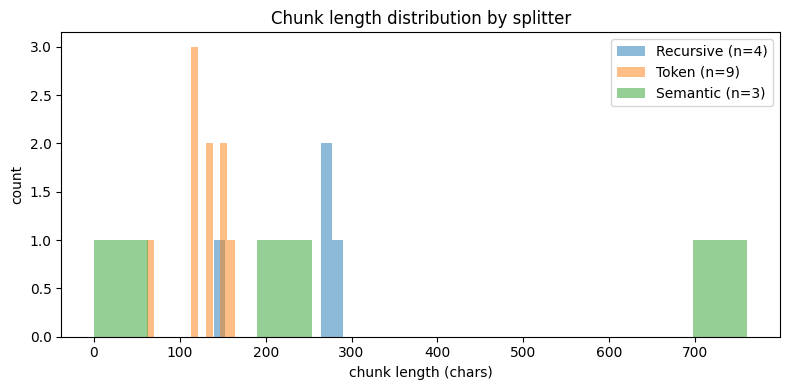

: 

In [ ]:
import matplotlib.pyplot as plt

all_strategies = {
    'Recursive': [len(c.page_content) for c in recursive_chunks],
    'Token': [len(c.page_content) for c in token_chunks],
}
if semantic_chunks:
    all_strategies['Semantic'] = [len(c.page_content) for c in semantic_chunks]

fig, ax = plt.subplots(figsize=(8, 4))
for name, lens in all_strategies.items():
    ax.hist(lens, bins=12, alpha=0.5, label=f'{name} (n={len(lens)})')
ax.set_xlabel('chunk length (chars)')
ax.set_ylabel('count')
ax.set_title('Chunk length distribution by splitter')
ax.legend()
plt.tight_layout()
plt.show()

## 정리

- 로더는 **다양한 소스를 동일한 `Document` 형식으로** 평준화한다.
- `SemanticChunker`는 일회성 토큰 비용이 든다(최초 1회 인덱싱시). 업데이트가 적은 금융 약관에 적합.
- 한국어는 **`kiwi.split_into_sents`로 먼저 문장 분리 → 청크 병합**이 실전에서 잘 동작.

## 더 읽어보기
- [LangChain Text Splitters 공식 문서](https://python.langchain.com/docs/concepts/text_splitters/)
- [Kiwi 형태소 분석기](https://github.com/bab2min/Kiwi) / [KSS Docs](https://github.com/hyunwoongko/kss)